In [ ]:
# -*- coding: utf-8 -*-
"""
Author: Dein Name
Datum:  29.09.2026
"""

'\nAuthor: Dein Name\nDatum:  29.09.2026\n'

File       : ../data/raw/raster/10300100E57BC400-visual_pre_north.tif
Size       : 17408 x 17408 px, 3 band(s), uint8
CRS        : EPSG:32735
Pixel size : (0.30517578125, 0.30517578125)
Bounds     : BoundingBox(left=709843.75, bottom=9779843.75, right=715156.25, top=9785156.25)
Nodata     : None
Band names : (None, None, None)


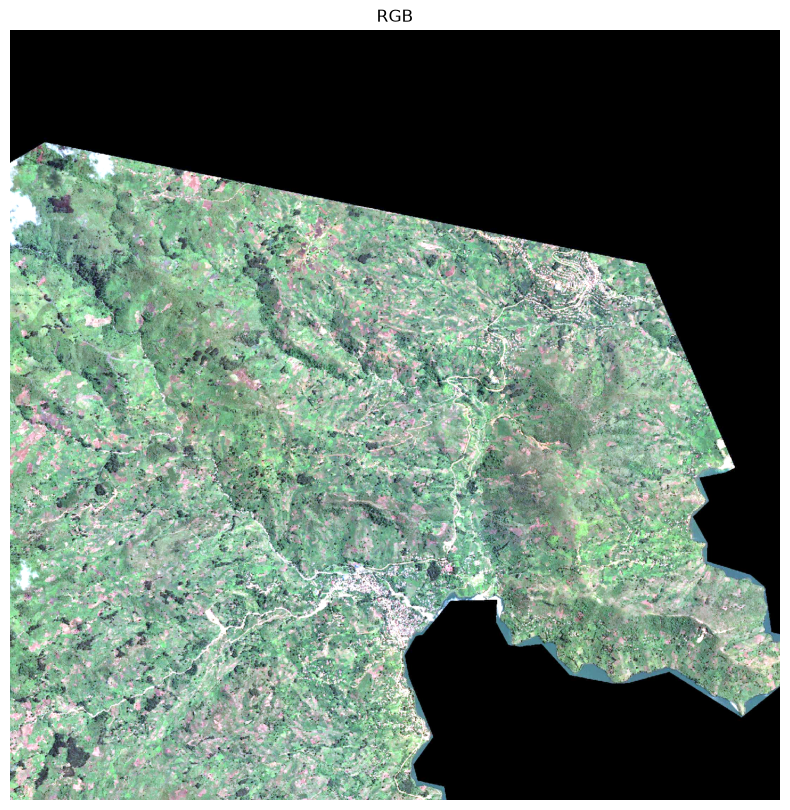

File       : ../data/raw/raster/10300100E57BC400-pan_pre_north.tif
Size       : 11180 x 11180 px, 1 band(s), uint16
CRS        : EPSG:32735
Pixel size : (0.4751788908765653, 0.4751788908765653)
Bounds     : BoundingBox(left=709843.75, bottom=9779843.75, right=715156.25, top=9785156.25)
Nodata     : None
Band names : (None,)


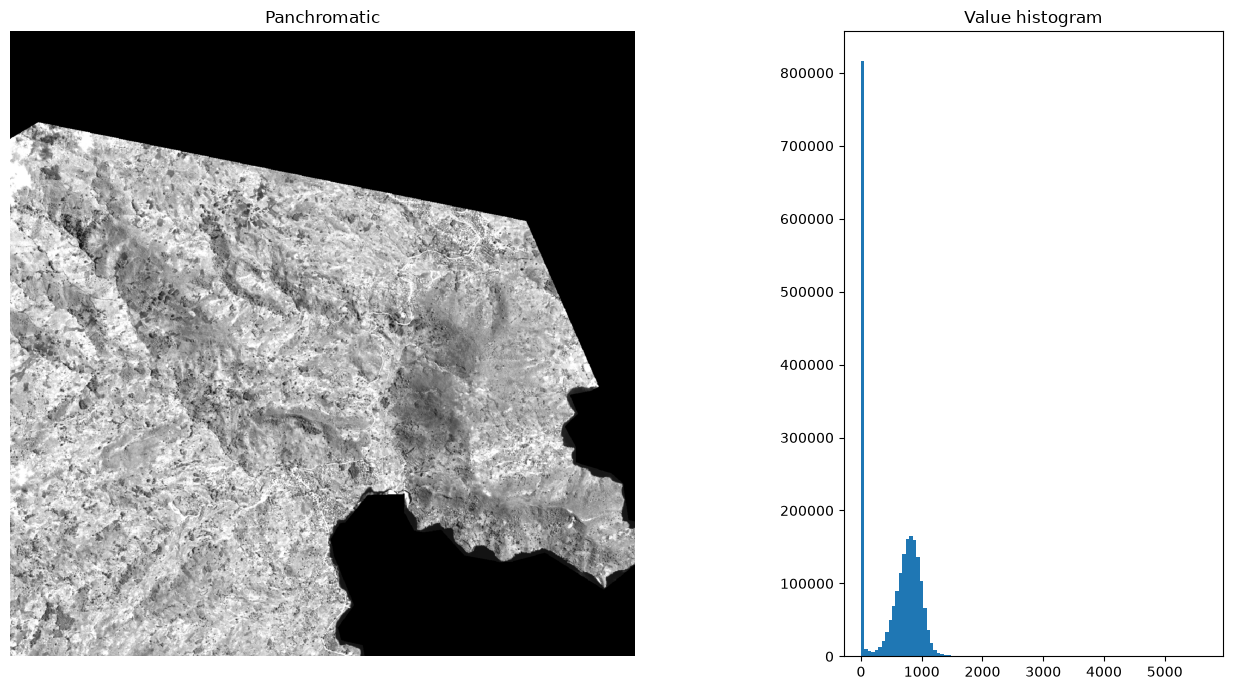

File       : ../data/raw/raster/10300100E57BC400-ms_pre_north.tif
Size       : 2795 x 2795 px, 8 band(s), uint16
CRS        : EPSG:32735
Pixel size : (1.9007155635062611, 1.9007155635062611)
Bounds     : BoundingBox(left=709843.75, bottom=9779843.75, right=715156.25, top=9785156.25)
Nodata     : None
Band names : (None, None, None, None, None, None, None, None)


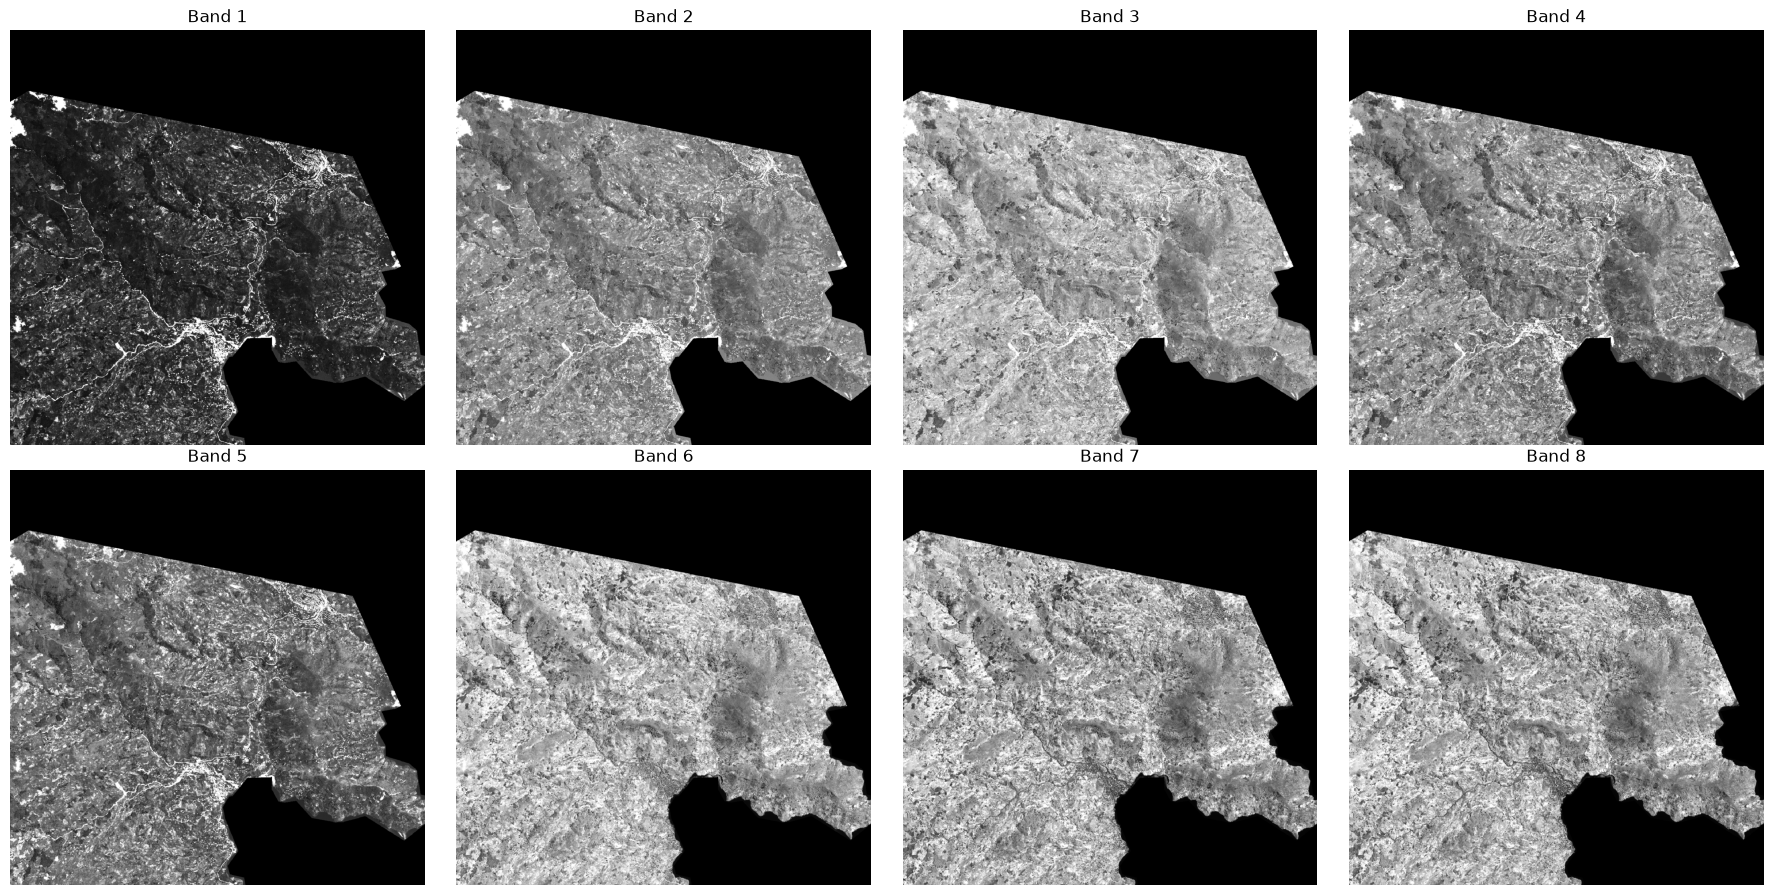

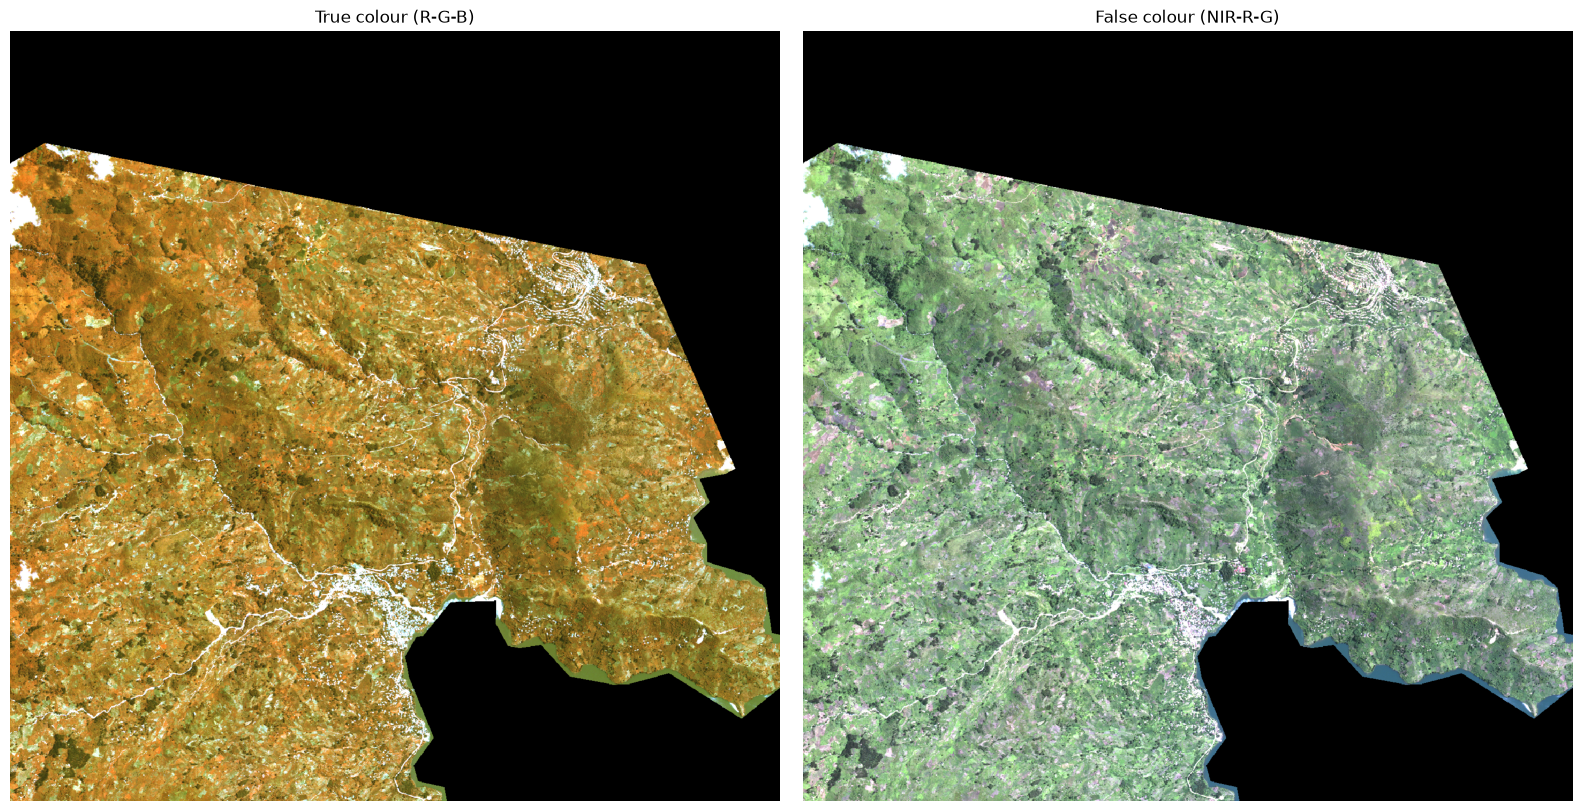

RGB   17408 x 17408  bands=3  pixel=0.305  crs=EPSG:32735
MS     2795 x 2795   bands=8  pixel=1.901  crs=EPSG:32735
PAN   11180 x 11180  bands=1  pixel=0.475  crs=EPSG:32735


In [1]:
# %% [markdown]
# # Simple TIF inspection
# pip install rasterio numpy matplotlib
# Run each "# %%" cell with Shift+Enter in VS Code.

# %% Config: put your file paths here (use pre or post, one at a time)
import numpy as np
import matplotlib.pyplot as plt
import rasterio

RGB_FILE = "../data/raw/raster/10300100E57BC400-visual_pre_north.tif"
MS_FILE  = "../data/raw/raster/10300100E57BC400-ms_pre_north.tif"
PAN_FILE = "../data/raw/raster/10300100E57BC400-pan_pre_north.tif"

# %% Helpers
def read_preview(path, max_size=1500):
    """Read the whole file, downsampled so the longest side is <= max_size px."""
    with rasterio.open(path) as src:
        scale = min(1.0, max_size / max(src.width, src.height))
        h, w = int(src.height * scale), int(src.width * scale)
        return src.read(out_shape=(src.count, h, w)).astype(np.float32)

def stretch(a, lo=2, hi=98):
    """Percentile contrast stretch to 0-1 so images are actually visible."""
    p1, p2 = np.percentile(a, (lo, hi))
    return np.clip((a - p1) / (p2 - p1 + 1e-9), 0, 1)

def rgb_image(arr, r, g, b):
    """arr: (bands, h, w) -> (h, w, 3) image from 0-based band indices."""
    return np.dstack([stretch(arr[i]) for i in (r, g, b)])

def info(path):
    with rasterio.open(path) as src:
        print(f"File       : {path}")
        print(f"Size       : {src.width} x {src.height} px, {src.count} band(s), {src.dtypes[0]}")
        print(f"CRS        : {src.crs}")
        print(f"Pixel size : {src.res}")
        print(f"Bounds     : {src.bounds}")
        print(f"Nodata     : {src.nodata}")
        print(f"Band names : {src.descriptions}")

# %% 1) Visual RGB image
info(RGB_FILE)
rgb = read_preview(RGB_FILE)
plt.figure(figsize=(10, 10))
plt.imshow(rgb_image(rgb, 0, 1, 2))
plt.title("RGB"); plt.axis("off"); plt.show()

# %% 2) Panchromatic image (single band, grayscale) + histogram
info(PAN_FILE)
pan = read_preview(PAN_FILE)[0]
fig, ax = plt.subplots(1, 2, figsize=(15, 7), gridspec_kw={"width_ratios": [3, 1]})
ax[0].imshow(stretch(pan), cmap="gray"); ax[0].set_title("Panchromatic"); ax[0].axis("off")
ax[1].hist(pan.ravel(), bins=100); ax[1].set_title("Value histogram")
plt.tight_layout(); plt.show()

# %% 3) Multispectral image: every band on its own
info(MS_FILE)
ms = read_preview(MS_FILE)
n = ms.shape[0]
cols = min(4, n)
rows = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows, cols, figsize=(4.5 * cols, 4.5 * rows), squeeze=False)
for i, ax in enumerate(axes.ravel()):
    if i < n:
        ax.imshow(stretch(ms[i]), cmap="gray"); ax.set_title(f"Band {i + 1}")
    ax.axis("off")
plt.tight_layout(); plt.show()

# %% 4) Multispectral as colour composites
# Set band numbers (1-based) for YOUR sensor. Defaults assume B, G, R, NIR order.
RED, GREEN, BLUE, NIR = 3, 2, 1, 4

fig, ax = plt.subplots(1, 2, figsize=(16, 8))
ax[0].imshow(rgb_image(ms, RED - 1, GREEN - 1, BLUE - 1)); ax[0].set_title("True colour (R-G-B)")
if n >= NIR:
    ax[1].imshow(rgb_image(ms, NIR - 1, RED - 1, GREEN - 1)); ax[1].set_title("False colour (NIR-R-G)")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()

# %% 5) Compare sizes/resolutions of the three files
for name, p in [("RGB", RGB_FILE), ("MS", MS_FILE), ("PAN", PAN_FILE)]:
    with rasterio.open(p) as s:
        print(f"{name:4} {s.width:>6} x {s.height:<6} bands={s.count}  pixel={s.res[0]:.3f}  crs={s.crs}")